<a href="https://colab.research.google.com/github/PSriChandana/Data-Imputation/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#%matplotlib inline

In [5]:
data=pd.read_excel("tripDetails.xlsx")
data.head()

,TripID,TripLength,MaxSpeed,MostFreqSpeed,TripDuration,Brakes,IdlingTime,Honking
0,1,21,51,14,93,307,27,112
1,2,148,130,106,156,226,5,114
2,3,18,38,16,100,351,26,107
3,4,22,43,48,36,17,4,5
4,5,183,108,90,171,88,5,29


In [6]:
data.drop(['TripID'],axis=1,inplace=True)#inplace is true as making changes in the same dataframe
data.head()

,TripLength,MaxSpeed,MostFreqSpeed,TripDuration,Brakes,IdlingTime,Honking
0,21,51,14,93,307,27,112
1,148,130,106,156,226,5,114
2,18,38,16,100,351,26,107
3,22,43,48,36,17,4,5
4,183,108,90,171,88,5,29


In [7]:
#to understand what each variable stands for and their units
features =list(data.columns)
print(features)

['TripLength', 'MaxSpeed', 'MostFreqSpeed', 'TripDuration', 'Brakes', 'IdlingTime', 'Honking']


In [8]:
units=['kms','kmph','kmph','mins','counts','mins','counts']
feature_units = dict(zip(features,units))
feature_units
#the zip funciton is used to combine elements
#into corresponding tuples which can then be
#converted to a dictionary with corresponding
#keys and values

{'TripLength': 'kms',
 'MaxSpeed': 'kmph',
 'MostFreqSpeed': 'kmph',
 'TripDuration': 'mins',
 'Brakes': 'counts',
 'IdlingTime': 'mins',
 'Honking': 'counts'}

In [9]:
data.info()
#no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TripLength     91 non-null     int64
 1   MaxSpeed       91 non-null     int64
 2   MostFreqSpeed  91 non-null     int64
 3   TripDuration   91 non-null     int64
 4   Brakes         91 non-null     int64
 5   IdlingTime     91 non-null     int64
 6   Honking        91 non-null     int64
dtypes: int64(7)
memory usage: 5.1 KB


In [10]:
data.describe()

,TripLength,MaxSpeed,MostFreqSpeed,TripDuration,Brakes,IdlingTime,Honking
count,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000
mean,70.769231,70.362637,50.648352,87.373626,135.439560,11.593407,49.923077
std,73.302126,34.509424,34.349632,47.123160,114.758607,9.796800,46.371023
min,16.000000,35.000000,12.000000,22.000000,14.000000,4.000000,4.000000
25%,20.000000,42.000000,15.500000,34.500000,36.500000,5.000000,20.000000
50%,21.000000,54.000000,42.000000,88.000000,100.000000,5.000000,25.000000
75%,163.000000,105.500000,89.000000,133.000000,198.000000,24.000000,97.500000
max,210.000000,138.000000,118.000000,171.000000,429.000000,32.000000,155.000000


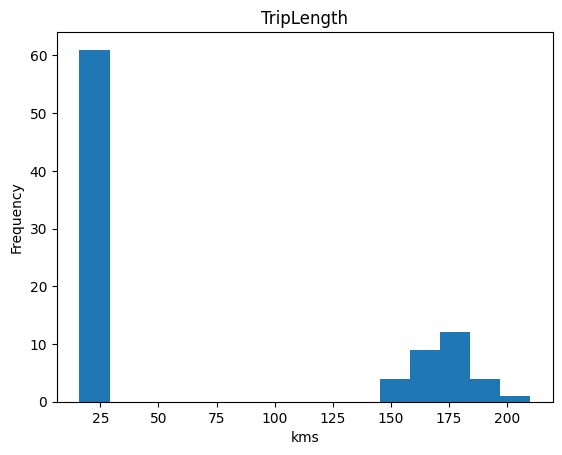

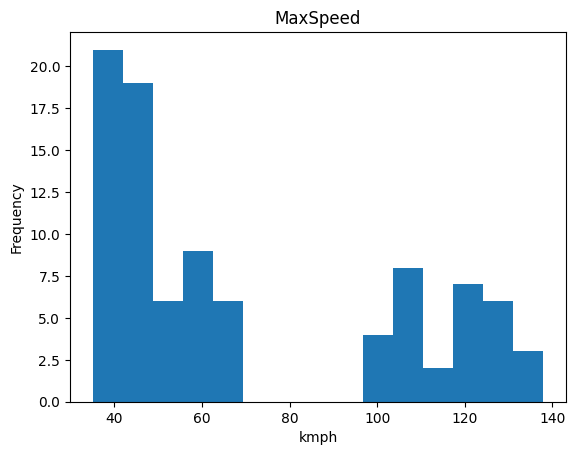

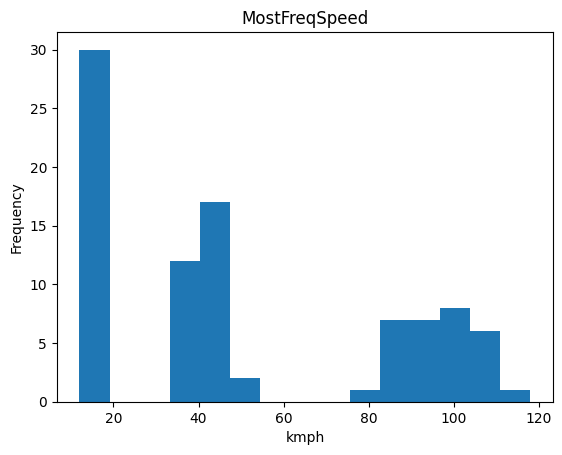

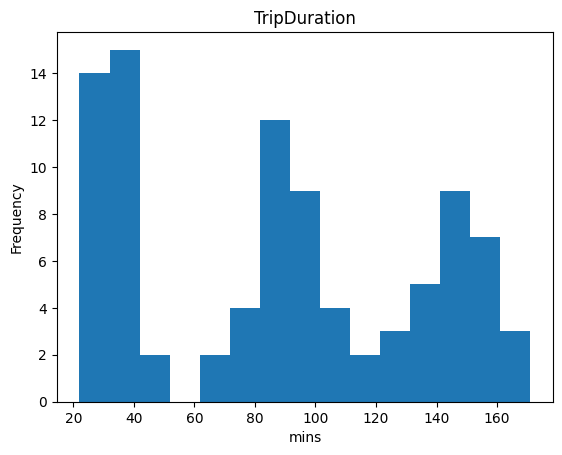

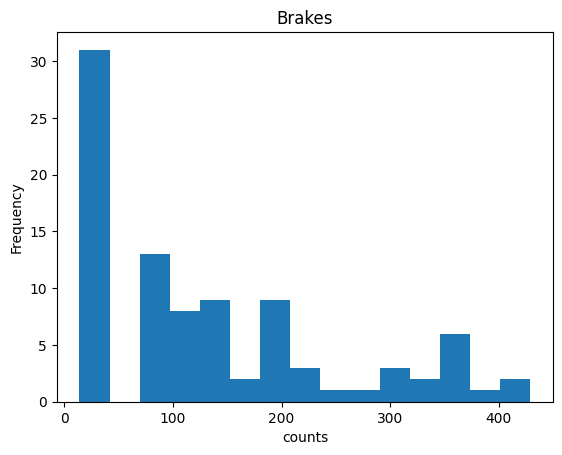

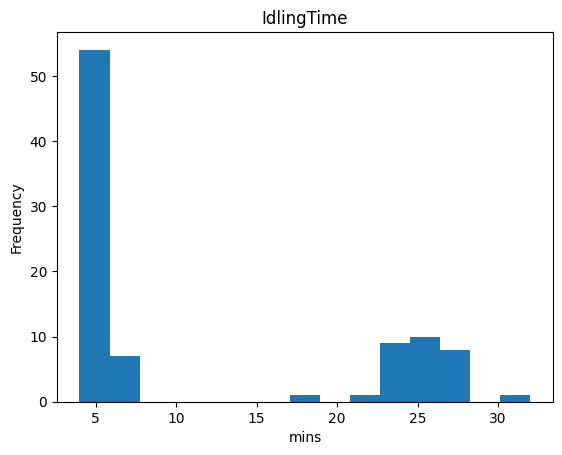

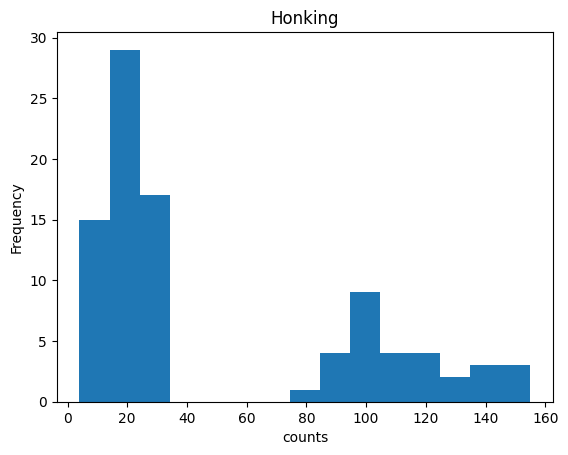

In [11]:
for item in features:
  data[item].plot(kind='hist',bins=15)
  plt.title(item)
  plt.xlabel(feature_units[item])
  plt.show()

  #From the histogram we can see that the
  #graphs are not continous , they are grouped,
  #so we can use k means clustering

In [12]:

#To look at the relationship between different features correlation
correlation=data.corr()
print(correlation)
#this tells us most are related

               TripLength  MaxSpeed  MostFreqSpeed  TripDuration    Brakes  \
TripLength       1.000000  0.933549       0.922928      0.842934  0.047158   
MaxSpeed         0.933549  1.000000       0.928592      0.730388  0.011993   
MostFreqSpeed    0.922928  0.928592       1.000000      0.632675 -0.182159   
TripDuration     0.842934  0.730388       0.632675      1.000000  0.416028   
Brakes           0.047158  0.011993      -0.182159      0.416028  1.000000   
IdlingTime      -0.471204 -0.564379      -0.726001      0.018913  0.641201   
Honking          0.429318  0.458151       0.309691      0.571365  0.778774   

               IdlingTime   Honking  
TripLength      -0.471204  0.429318  
MaxSpeed        -0.564379  0.458151  
MostFreqSpeed   -0.726001  0.309691  
TripDuration     0.018913  0.571365  
Brakes           0.641201  0.778774  
IdlingTime       1.000000  0.160450  
Honking          0.160450  1.000000  


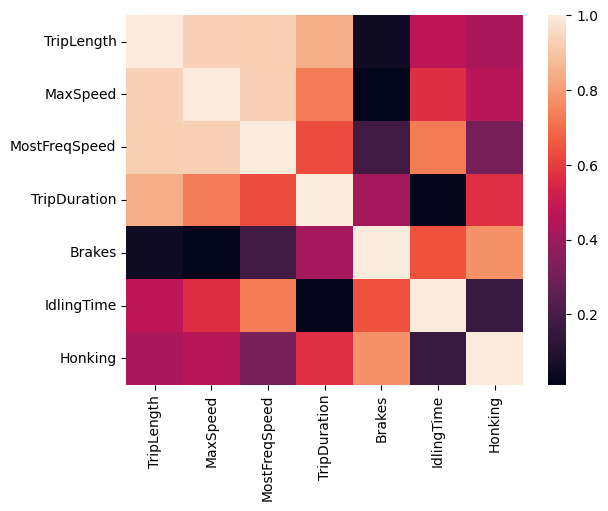

In [13]:
#using heatmap to see visually the correlation
#heatmap -> seaborn
sns.heatmap(np.abs(correlation),xticklabels=correlation.columns, yticklabels= correlation.columns)
plt.show()


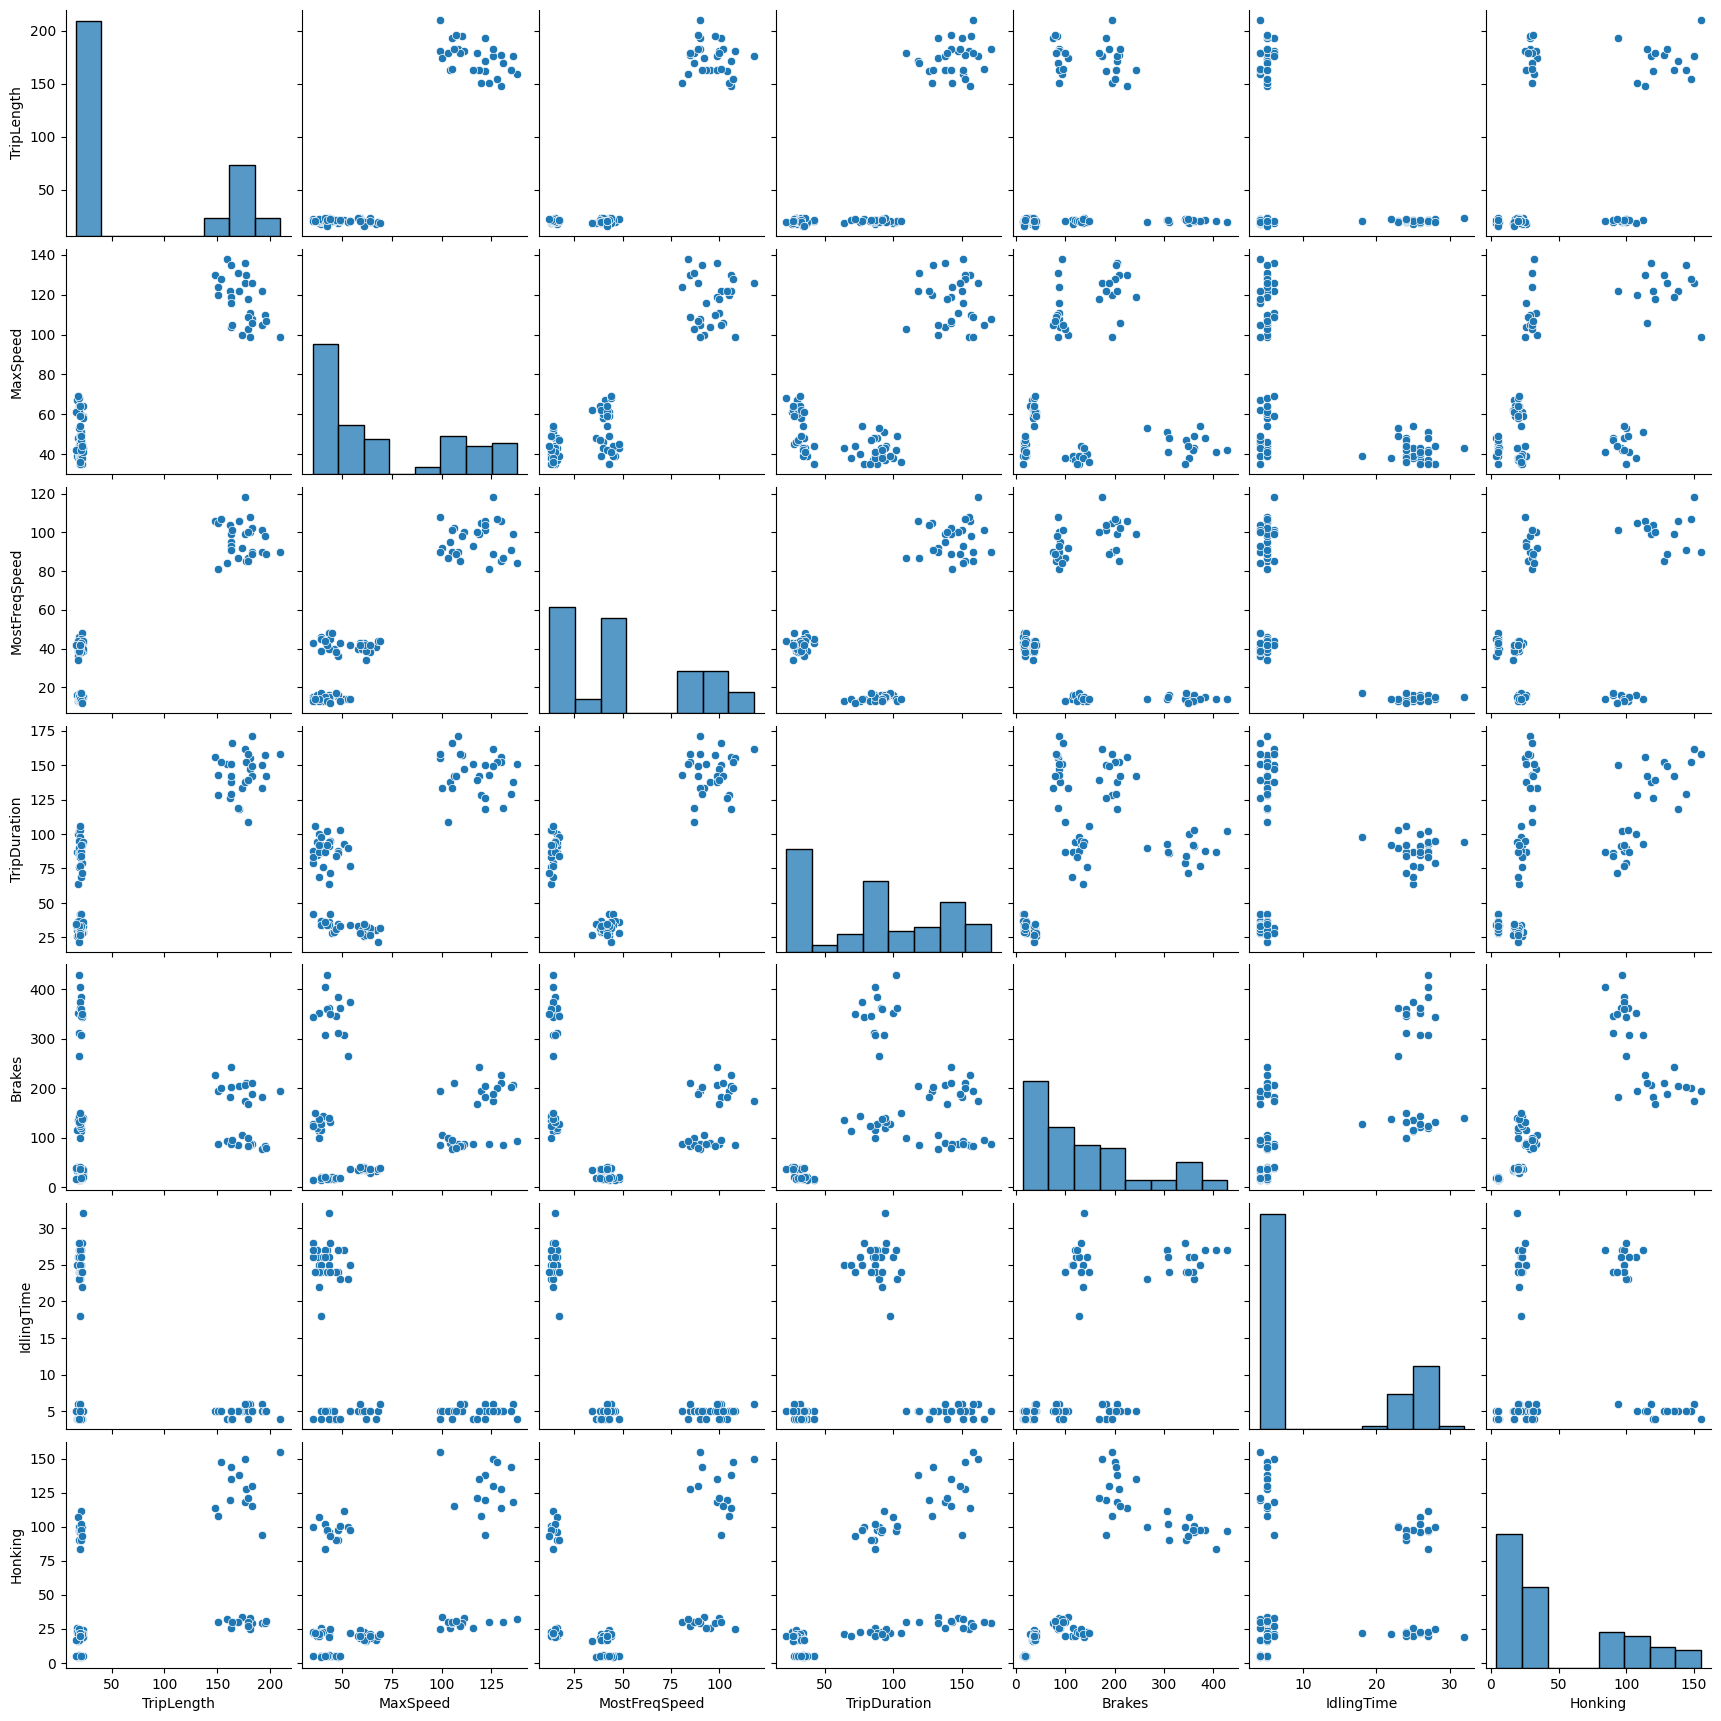

In [14]:
sns.pairplot(data)#scatter plots for all combination of data
plt.show()
#gives an idea about groups


In [15]:
#Scaling before K-means algo because we need to find Euclidean distance
#using standard scaling (xi-u)/sigma
from sklearn.preprocessing import StandardScaler
import copy as cp


In [16]:
data2=data.copy()
data2=StandardScaler().fit_transform(data2.values)
data2=pd.DataFrame(data2,columns = features)

**K-Means Clustering**
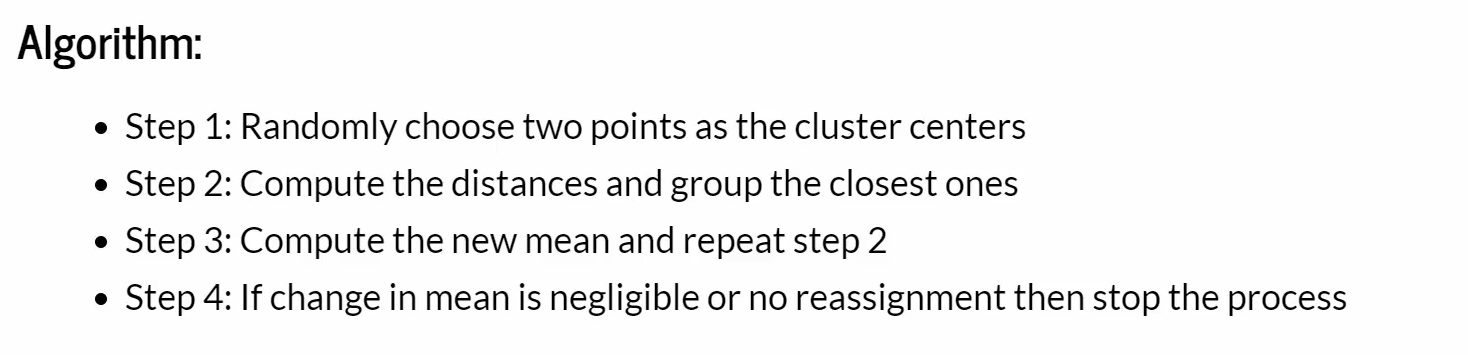
We need two inputs- data points and number of clusters

In [19]:
from sklearn import cluster

Determining number of clusters:

**Elbow Method**- looks at % of variance explained as a function of number of clusters
The point where marginal decrease plateaus is an indicator of optimal number of clusters


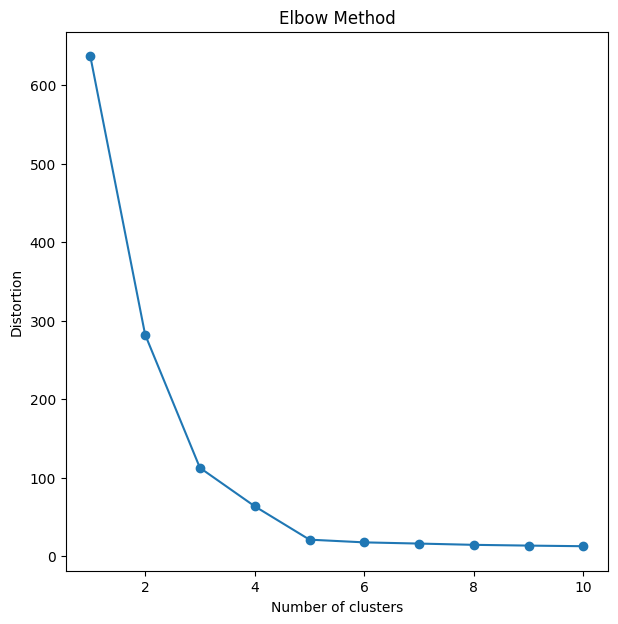

In [25]:
distortions=[]
for i in range(1,11):
  km=cluster.KMeans(n_clusters=i, init='k-means++',n_init=10,max_iter=300,random_state =100)
  km.fit(data2.values)
  distortions.append(km.inertia_)
  #Plotting elbow graph
plt.figure(figsize=(7,7))
plt.plot(range(1,11), distortions, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

the value plateaus at 3 number of clusters

In [26]:
k=3
km3=cluster.KMeans(n_clusters=k,init='k-means++',n_init=10,max_iter =300,random_state=100)
km3.fit(data2.values)

KMeans(n_clusters=3, n_init=10, random_state=100)

In [27]:
labels=km3.labels_
Ccenters = km3.cluster_centers_
data2['labels']=labels
data2['labels']=data2['labels'].astype('str')
print(data2['labels'])

0     2
1     1
2     2
3     0
4     1
     ..
86    2
87    1
88    2
89    1
90    0
Name: labels, Length: 91, dtype: object


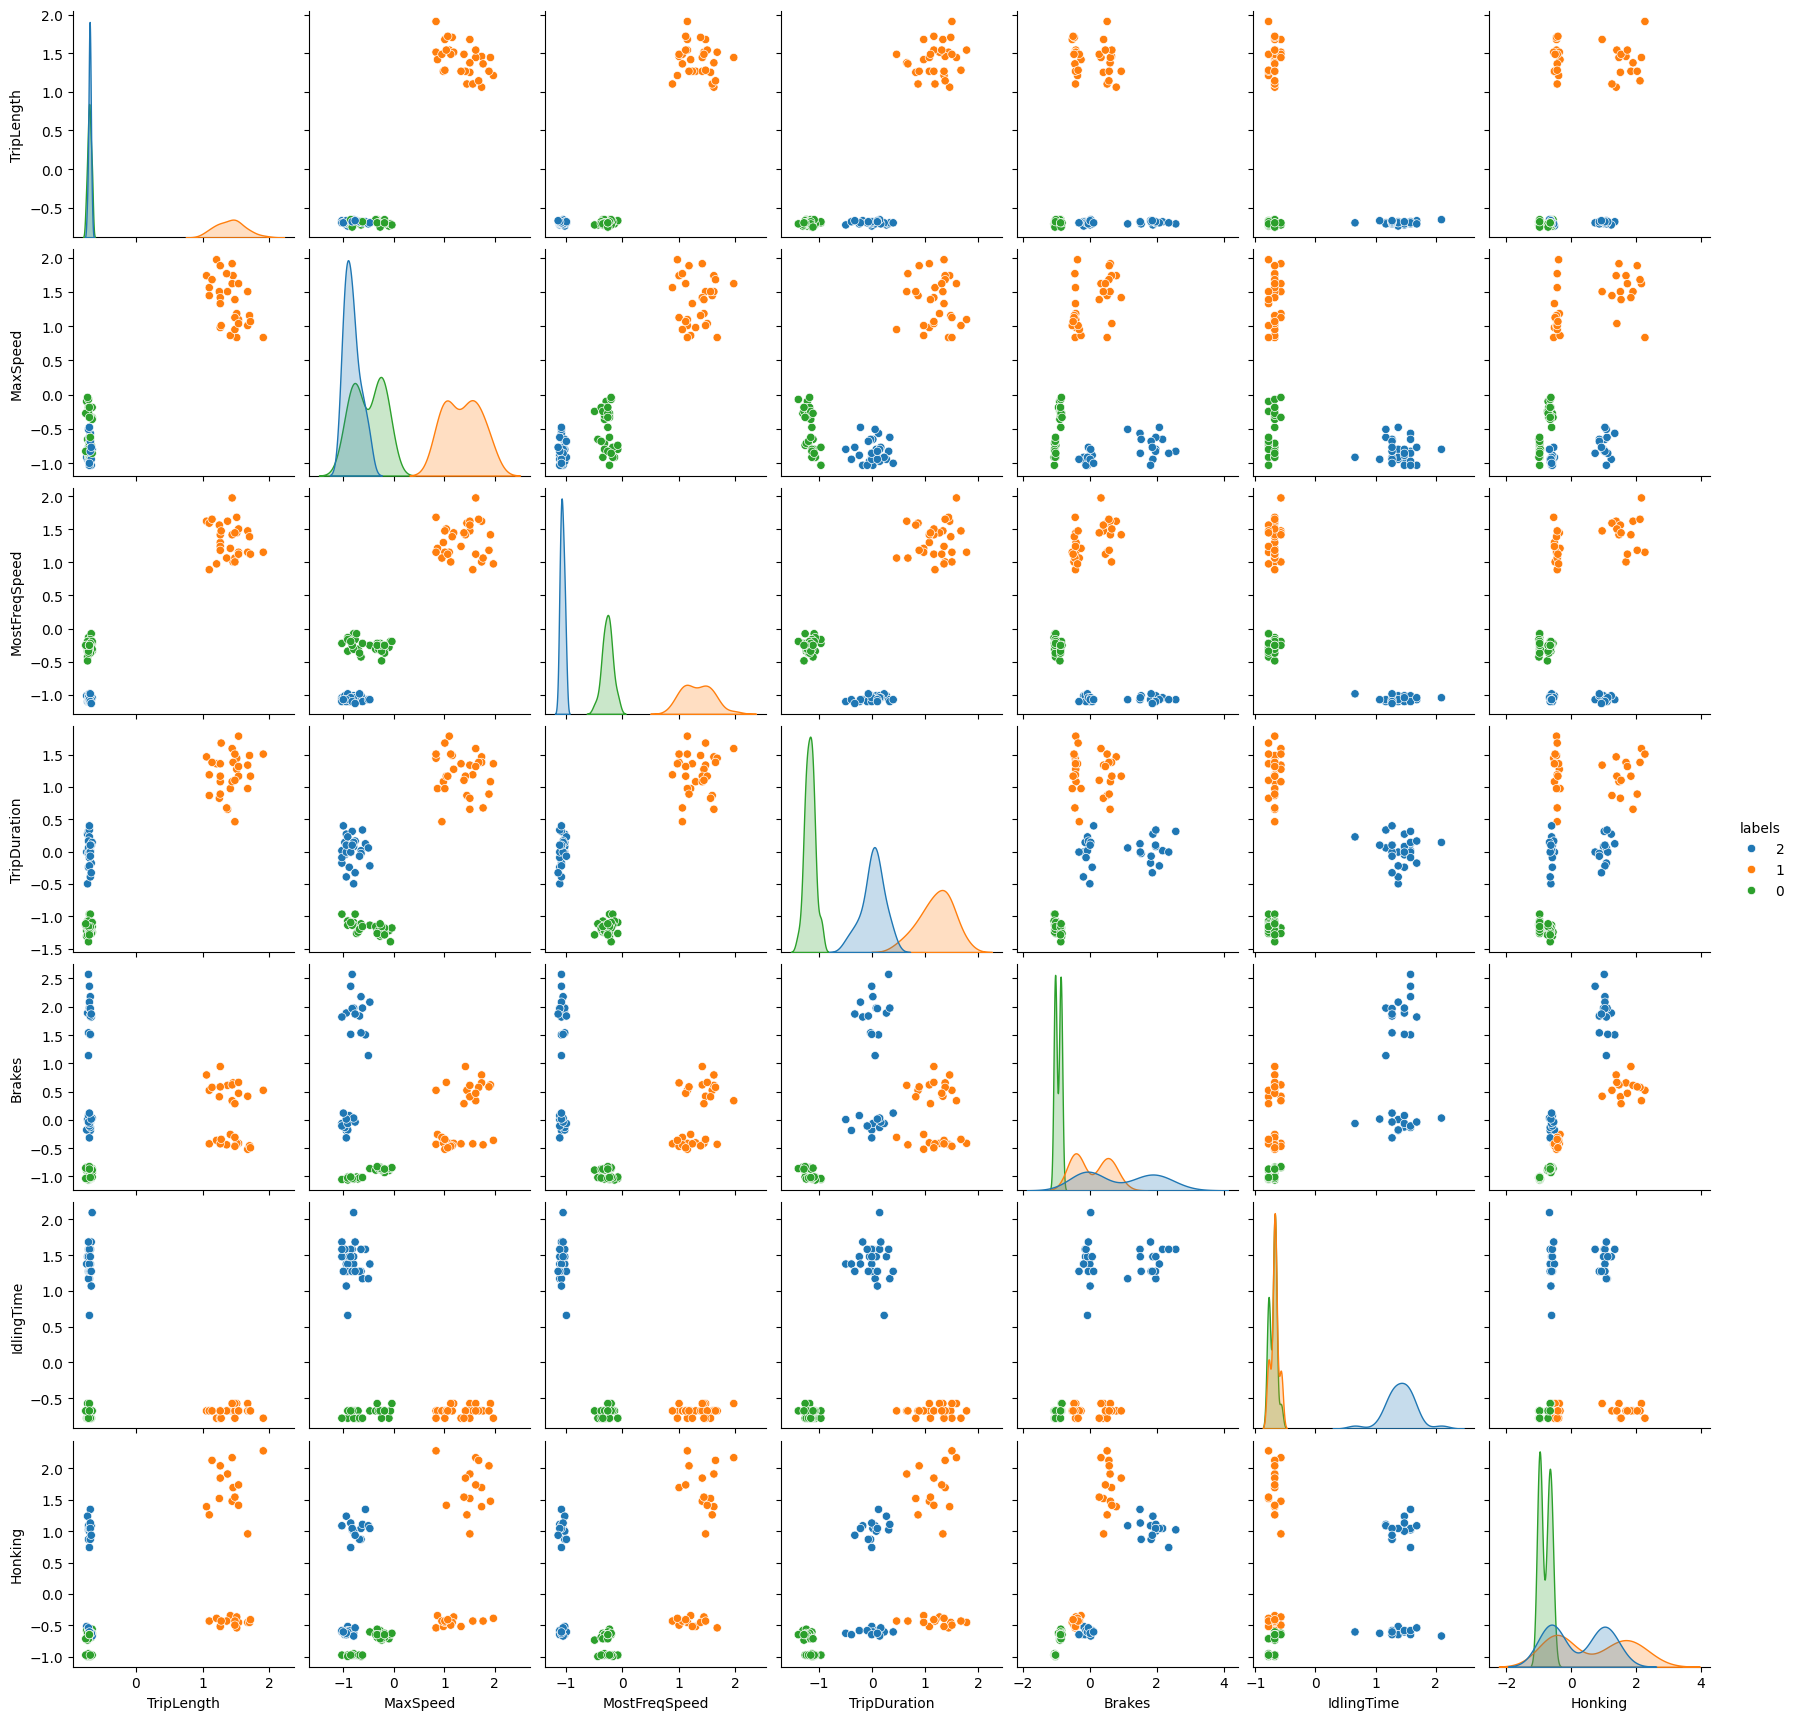

In [30]:
sns.pairplot(data2, x_vars=features, y_vars=features, hue='labels',diag_kind='kde')
plt.show()

In [32]:
c_df = pd.concat([
    data[data2['labels']=='0'].mean(),
    data[data2['labels']=='1'].mean(),
    data[data2['labels']=='2'].mean()
], axis=1)
c_df

,0,1,2
TripLength,19.838710,174.000000,20.166667
MaxSpeed,52.806452,116.966667,41.900000
MostFreqSpeed,41.677419,96.066667,14.500000
TripDuration,32.129032,143.800000,88.033333
Brakes,27.161290,143.866667,238.900000
IdlingTime,4.709677,4.966667,25.333333
Honking,12.516129,78.633333,59.866667


cluster 1 is mostly the highway trips during the leisure hours
cluster 0 is mostly to be the highway trips during the non-leisure hours on the highway

**NOW ASSIGNING THE LABELS TO CLUSTERS**


In [33]:
triptype=['Intercity-Peak hours','Highway','Intercity-Non-peak hours']
data['labels']=labels
data['labels']=data['labels'].map({0:triptype[0],1:triptype[1],2:triptype[2]})

In [34]:
print(data.head())

   TripLength  MaxSpeed  MostFreqSpeed  TripDuration  Brakes  IdlingTime  \
0          21        51             14            93     307          27   
1         148       130            106           156     226           5   
2          18        38             16           100     351          26   
3          22        43             48            36      17           4   
4         183       108             90           171      88           5   

   Honking                    labels  
0      112  Intercity-Non-peak hours  
1      114                   Highway  
2      107  Intercity-Non-peak hours  
3        5      Intercity-Peak hours  
4       29                   Highway  
